In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from xgboost import XGBClassifier,plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data for projects/covtype.csv')
df.sample(10)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
293259,3080,100,13,190,67,2148,242,221,107,3545,...,0,0,0,0,0,0,0,0,0,1
312235,3169,100,10,404,104,594,237,227,120,685,...,0,0,0,0,0,0,0,0,0,1
517155,2929,322,18,85,-1,2837,172,219,186,2096,...,0,0,0,0,0,0,0,0,0,1
384287,2934,21,10,743,136,3212,214,219,141,780,...,0,0,0,0,0,0,0,0,0,2
384240,3091,170,19,1024,148,3230,230,244,137,1855,...,0,1,0,0,0,0,0,0,0,2
327941,3197,1,12,277,70,1333,203,217,152,511,...,0,0,0,0,0,0,0,0,0,1
409797,3268,7,14,469,75,1222,202,212,145,362,...,0,0,0,0,0,0,0,0,0,1
8315,2542,136,19,120,20,1116,246,228,102,1744,...,0,0,0,0,0,0,0,0,0,3
458617,3346,303,12,524,109,3247,188,234,187,3412,...,1,0,0,0,0,0,0,0,0,7
230618,3318,276,7,240,50,3342,201,242,179,1650,...,0,0,0,0,0,0,1,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [ ]:
 df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']
le=LabelEncoder()
encoded_y=le.fit_transform(y)
encoded_y=pd.DataFrame(encoded_y,columns=['Cover_Type'])
X_train, X_test, y_train, y_test = train_test_split(
    X, encoded_y,
    test_size=0.2,
    random_state=42,
    stratify=encoded_y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled,
                          columns=X_train.columns,
                          index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled,
                         columns=X_test.columns,
                         index=X_test.index)

n_train = min(10000, len(X_train_df))
n_test = min(10000, len(X_test_df))

X_train_sample = X_train_df.sample(n=n_train, random_state=42)
X_test_sample  = X_test_df.sample(n=n_test, random_state=42)

y_train_sample = y_train.loc[X_train_sample.index]
y_test_sample  = y_test.loc[X_test_sample.index]


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sample, y_train_sample)
y_pred=rf.predict(X_test_sample)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
print("rf accuracy score",accuracy_score(y_test_sample,y_pred))

rf accuracy score 0.8177


In [ ]:
xgb=XGBClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sample,y_train_sample)
y_pred_xgb=xgb.predict(X_test_sample)

In [ ]:
print("xgb accuracy score",accuracy_score(y_test_sample,y_pred_xgb))

xgb accuracy score 0.8208


In [ ]:
print("\t Random-Forest-classification-report\n",classification_report(y_test_sample, y_pred))

	 Random-Forest-classification-report
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      3697
           1       0.82      0.88      0.85      4855
           2       0.75      0.87      0.81       630
           3       0.85      0.48      0.61        48
           4       0.82      0.18      0.29       152
           5       0.74      0.40      0.52       276
           6       0.91      0.71      0.80       342

    accuracy                           0.82     10000
   macro avg       0.82      0.62      0.67     10000
weighted avg       0.82      0.82      0.81     10000



In [ ]:
print("\t Xgboost-classification-report\n",classification_report(y_test_sample, y_pred_xgb))

	 Xgboost-classification-report
               precision    recall  f1-score   support

           0       0.82      0.81      0.82      3697
           1       0.83      0.87      0.85      4855
           2       0.78      0.84      0.81       630
           3       0.82      0.65      0.72        48
           4       0.72      0.30      0.43       152
           5       0.66      0.47      0.55       276
           6       0.91      0.73      0.81       342

    accuracy                           0.82     10000
   macro avg       0.79      0.67      0.71     10000
weighted avg       0.82      0.82      0.82     10000



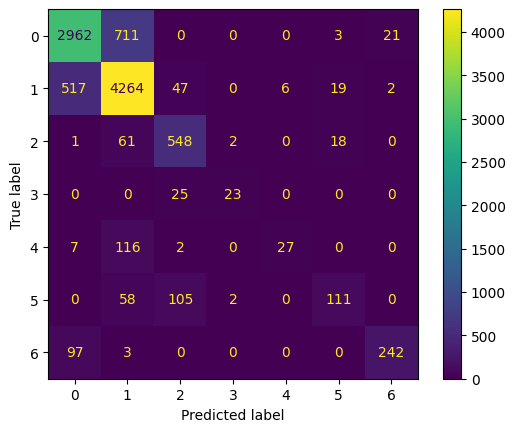

In [ ]:
cm=ConfusionMatrixDisplay(confusion_matrix(y_test_sample,y_pred))
cm.plot()

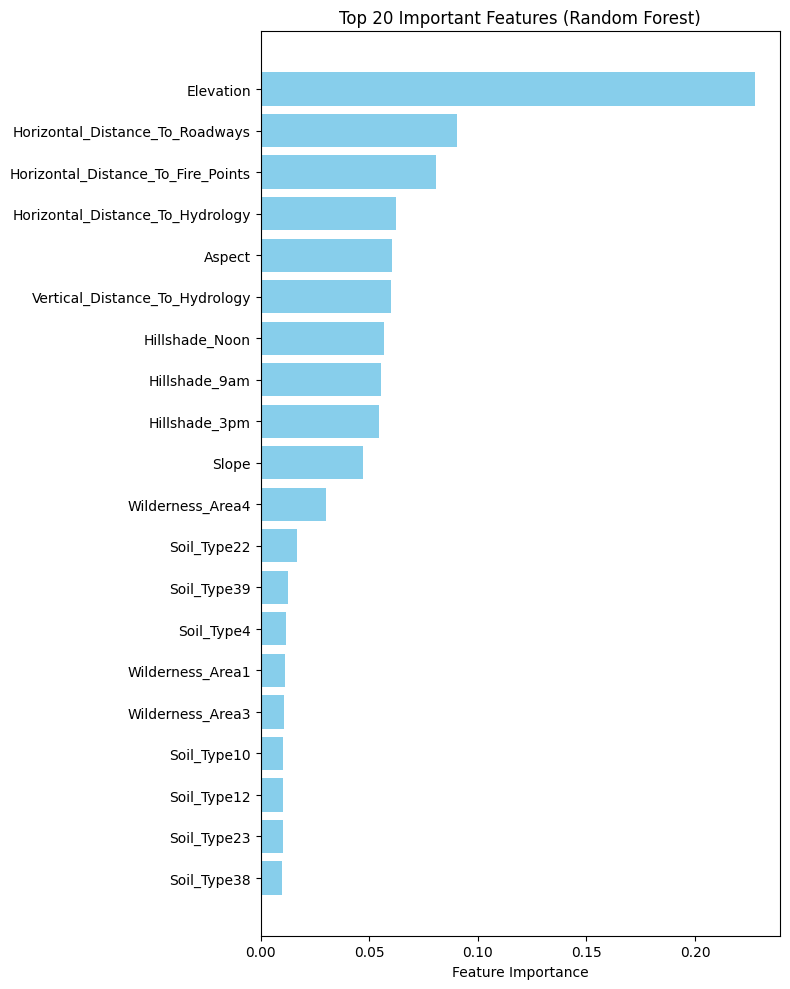

In [ ]:
importances = rf.feature_importances_
feature_names = X_train.columns

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features (Random Forest)")
plt.tight_layout()
plt.show()


<Figure size 1000x1200 with 0 Axes>

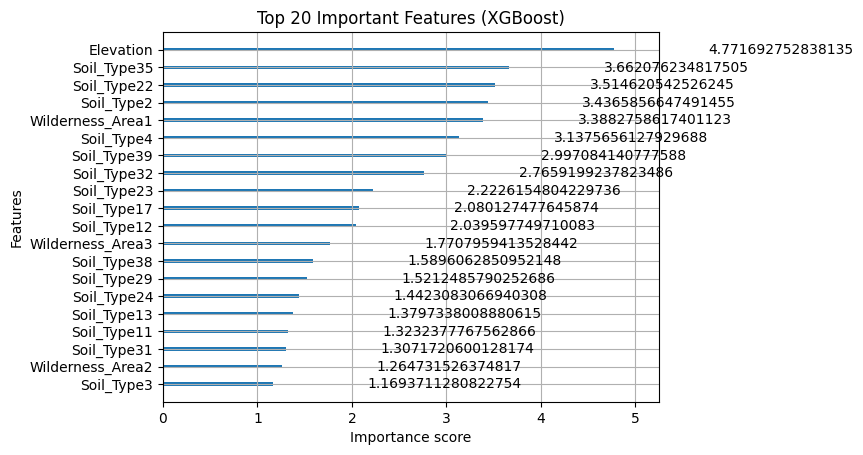

In [ ]:
plt.figure(figsize=(10, 12))
plot_importance(xgb, max_num_features=20, importance_type='gain')
plt.title("Top 20 Important Features (XGBoost)")
plt.show()